In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import pandas as pd
import matplotlib.pyplot as plt

base_path = "/content/drive/MyDrive/f1_pit_strategy/data/raw/"

lap_times = pd.read_csv(base_path + "lap_times.csv")
pit_stops = pd.read_csv(base_path + "pit_stops.csv")


Mounted at /content/drive


In [ ]:
race_id = 1136
driver_id = 830

driver_laps = lap_times[(lap_times['raceId'] == race_id) &(lap_times['driverId'] == driver_id)].sort_values('lap')
driver_pits = pit_stops[(pit_stops['raceId'] == race_id) &(pit_stops['driverId'] == driver_id)]
driver_pits.head()

,raceId,driverId,stop,lap,time,duration,milliseconds
11105,1136,830,1,22,15:34:56,28.198,28198
11118,1136,830,2,41,16:01:54,24.150,24150


In [ ]:
driver_laps_clean = driver_laps[~driver_laps['lap'].isin(driver_pits['lap'])].copy()
driver_laps_clean.head()

,raceId,driverId,lap,position,time,milliseconds
579876,1136,830,1,6,1:30.354,90354
579877,1136,830,2,6,1:26.170,86170
579878,1136,830,3,6,1:25.855,85855
579879,1136,830,4,6,1:25.633,85633
579880,1136,830,5,6,1:25.218,85218


In [ ]:
driver_laps_clean['tyre_age'] = 0
last_pit_lap = 0
pit_laps = sorted(driver_pits['lap'].tolist())

for idx, row in driver_laps_clean.iterrows():
    lap = row['lap']
    if lap > last_pit_lap and pit_laps and lap > pit_laps[0]:
        last_pit_lap = pit_laps.pop(0)
    driver_laps_clean.at[idx, 'tyre_age'] = lap - last_pit_lap
driver_laps_clean[['lap', 'tyre_age']].head(25)


,lap,tyre_age
579876,1,1
579877,2,2
579878,3,3
579879,4,4
579880,5,5
579881,6,6
579882,7,7
579883,8,8
579884,9,9
579885,10,10


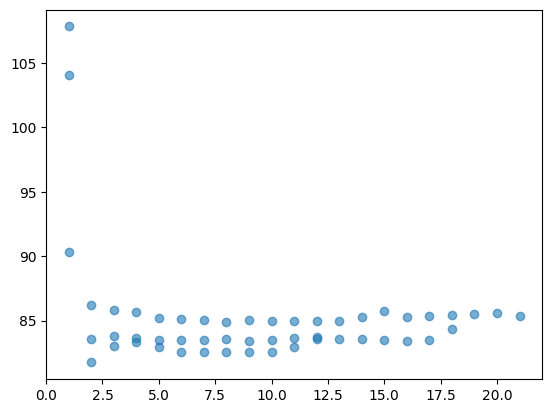

In [ ]:
import matplotlib.pyplot as plt

driver_laps_clean['lap_number'] = driver_laps_clean['lap']
driver_laps_clean['lap_time_sec'] = driver_laps_clean['milliseconds'] / 1000
plt.scatter(driver_laps_clean['tyre_age'],driver_laps_clean['lap_time_sec'],alpha=0.6)

In [ ]:
driver_laps_clean[['lap_number', 'tyre_age', 'lap_time_sec']].head()

,lap_number,tyre_age,lap_time_sec
579876,1,1,90.354
579877,2,2,86.170
579878,3,3,85.855
579879,4,4,85.633
579880,5,5,85.218


In [ ]:

first_pit_lap = driver_pits['lap'].min()
stint_laps = driver_laps_clean[driver_laps_clean['lap'] < first_pit_lap].copy()

In [ ]:
X = stint_laps[['tyre_age']]
y = stint_laps['lap_time_sec']

split_idx = int(0.8 * len(stint_laps))

X_train = X.iloc[:split_idx]
X_test = X.iloc[split_idx:]
y_train = y.iloc[:split_idx]
y_test = y.iloc[split_idx:]

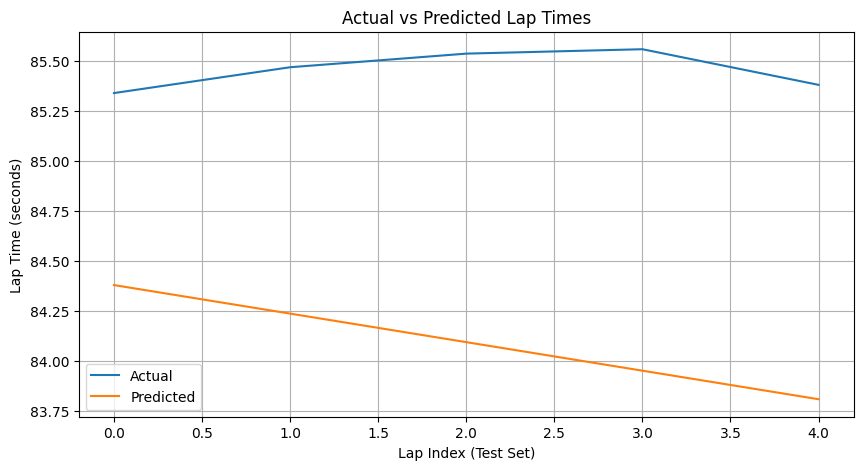

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

plt.figure(figsize=(10,5))
plt.plot(y_test.values, label="Actual")
plt.plot(y_pred, label="Predicted")
plt.xlabel("Lap Index (Test Set)")
plt.ylabel("Lap Time (seconds)")
plt.title("Actual vs Predicted Lap Times")
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
driver_laps_clean[['tyre_age']].corr()


,tyre_age
tyre_age,1.0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


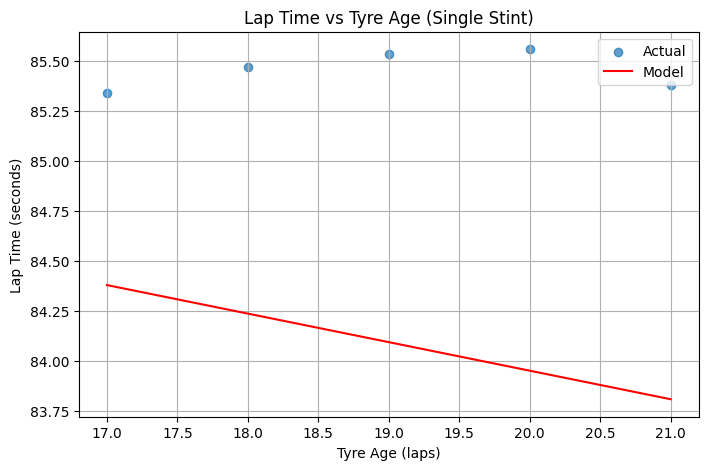

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Scatter actual
plt.scatter(
    X_test['tyre_age'],
    y_test,
    label='Actual',
    alpha=0.7
)

# Regression line
x_line = np.linspace(X_test['tyre_age'].min(), X_test['tyre_age'].max(), 100)
y_line = model.predict(x_line.reshape(-1, 1))

plt.plot(x_line, y_line, color='red', label='Model')

plt.xlabel("Tyre Age (laps)")
plt.ylabel("Lap Time (seconds)")
plt.title("Lap Time vs Tyre Age (Single Stint)")
plt.legend()
plt.grid(True)
plt.show()
